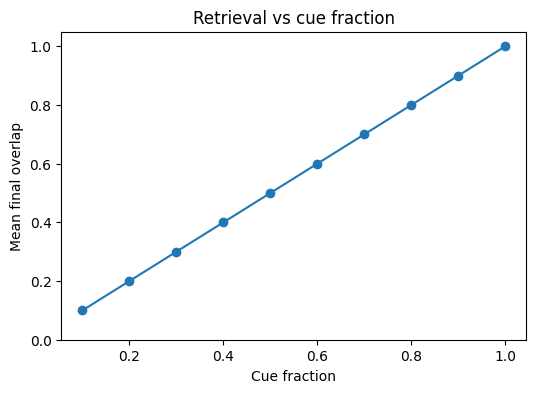

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, corrupt_pattern, generate_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success

n_neurons = 2000
sparsity = 0.1
corruption_level = 0.6
beta = 1.0
theta = 0.0

cue_fractions = np.linspace(0.1, 1.0, 10)
n_trials = 20

mean_overlaps = []
mean_successes = []

for cue_fraction in cue_fractions:
    overlaps = []
    successes = []

    for trial in range(n_trials):
        rng = np.random.default_rng(trial)

        pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        corrupted = corrupt_pattern(pattern, corruption_level, rng=rng)
        cs_input = generate_cs_input(pattern, cue_fraction, rng=rng)

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory = net.run(
            initial_state=corrupted,
            external_input=cs_input,
            beta=beta,
            theta=theta,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))

plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_overlaps, marker="o")
plt.xlabel("Cue fraction")
plt.ylabel("Mean final overlap")
plt.title("Retrieval vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

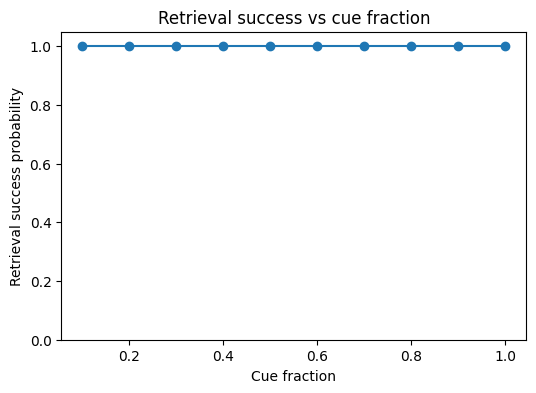

In [2]:
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_successes, marker="o")
plt.xlabel("Cue fraction")
plt.ylabel("Retrieval success probability")
plt.title("Retrieval success vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import (
    generate_sparse_pattern,
    corrupt_pattern,
    generate_noisy_cs_input,
)
from engram.hopfield import HopfieldNetwork
from engram.metrics import (
    pattern_overlap,
    retrieval_success,
    activity_fraction,
    convergence_steps,
)

# -------------------------
# Fixed parameters
# -------------------------
n_neurons = 2000
sparsity = 0.10
corruption_level = 0.60
beta = 1.0
theta = 0.0
background_fraction = 0.05
n_trials = 20

cue_fractions = np.linspace(0.1, 1.0, 10)

mean_overlaps = []
mean_successes = []
mean_final_activity = []
mean_steps = []

for cue_fraction in cue_fractions:
    overlaps = []
    successes = []
    activities = []
    steps_list = []

    for trial in range(n_trials):
        rng = np.random.default_rng(10000 + trial)

        pattern = generate_sparse_pattern(
            n_neurons=n_neurons,
            sparsity=sparsity,
            rng=rng,
        )

        # Start from zero state so the cue does the retrieval work
        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory = net.run(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            max_steps=50,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))
        activities.append(activity_fraction(final_state))
        steps_list.append(convergence_steps(trajectory))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))
    mean_final_activity.append(np.mean(activities))
    mean_steps.append(np.mean(steps_list))

# -------------------------
# Plot 1: overlap
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_overlaps, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Mean final overlap")
plt.title("Retrieval vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 2: success
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_successes, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Retrieval success probability")
plt.title("Retrieval success vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 3: final activity
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_final_activity, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Final activity fraction")
plt.title("Final network activity vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 4: convergence steps
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_steps, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Mean convergence steps")
plt.title("Convergence vs cue fraction")
plt.show()